# PINN Training on Google Colab - Full 100 Epochs

This notebook runs the complete PINN training pipeline on GPU.

**Instructions:**
1. Upload `pinn_training.zip` to Colab (use Files panel on left)
2. Enable GPU: Runtime → Change runtime type → GPU → Save
3. Run all cells: Runtime → Run all
4. Training will take 30-45 minutes on GPU
5. Download results at the end

---

## Step 1: Check GPU Availability

In [1]:
# Verify GPU is available
import torch
print(f"GPU Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("WARNING: No GPU detected! Training will be slow on CPU.")

GPU Available: True
GPU Name: Tesla T4
GPU Memory: 15.64 GB


## Step 2: Upload and Extract Files

In [2]:
from google.colab import files
import zipfile
import os
import glob

# Check if pinn_training directory already exists
if os.path.exists('/content/pinn_training') and os.path.isdir('/content/pinn_training'):
    print("✓ pinn_training directory already exists!")
    print("Skipping upload and extraction.")
    print("\nDirectory structure:")
    !ls -la /content/pinn_training/
else:
    # Look for any pinn_training*.zip file
    zip_files = glob.glob('/content/pinn_training*.zip')

    if zip_files:
        # Use the first matching ZIP file
        zip_path = zip_files[0]
        print(f"✓ Found {os.path.basename(zip_path)}")
        print("Extracting...")

        # Extract
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall('/content/')

        print("Files extracted successfully!")

        # Verify extraction
        if os.path.exists('/content/pinn_training'):
            print("\n✓ Directory structure:")
            !ls -la /content/pinn_training/
        else:
            print("\n⚠ Warning: pinn_training directory not found after extraction")
            print("Checking /content/ directory:")
            !ls -la /content/
    else:
        print("⚠ pinn_training.zip not found in /content/")
        print("Please upload pinn_training.zip using the Files panel (left sidebar)")
        print("Then re-run this cell.")

✓ Found pinn_training.zip
Extracting...
Files extracted successfully!

✓ Directory structure:
total 32
drwxr-xr-x 7 root root 4096 Apr  4 13:15 .
drwxr-xr-x 1 root root 4096 Apr  4 13:15 ..
drwxr-xr-x 2 root root 4096 Apr  4 13:15 artifacts
drwxr-xr-x 2 root root 4096 Apr  4 13:15 configs
drwxr-xr-x 3 root root 4096 Apr  4 13:15 eval
-rw-r--r-- 1 root root  123 Apr  4 13:15 requirements_colab.txt
drwxr-xr-x 8 root root 4096 Apr  4 13:15 src
drwxr-xr-x 2 root root 4096 Apr  4 13:15 training


## Step 3: Install Dependencies

In [3]:
# Install required packages
!pip install -q -r /content/pinn_training/requirements_colab.txt

print("Dependencies installed!")

Dependencies installed!


## Step 4: Setup Python Path and Verify Imports

In [4]:
import sys
import os

# Add pinn_training to Python path
sys.path.insert(0, '/content/pinn_training')

# Change to pinn_training directory
os.chdir('/content/pinn_training')

# Verify directory structure
print("Current directory:", os.getcwd())
print("\nChecking for src directory:")
if os.path.exists('src'):
    print("✓ src/ directory found")
    print("\nContents of src/:")
    !ls -la src/
else:
    print("✗ src/ directory NOT found")
    print("\nContents of /content/pinn_training/:")
    !ls -la /content/pinn_training/

# Try imports
try:
    from src.pinn.models.hybrid_pinn import HybridPINN
    from src.pinn.data.dataset_k_ahead import prepare_k_ahead_data
    print("\n✓ Imports successful!")
except ImportError as e:
    print(f"\n✗ Import failed: {e}")
    print("\nDebugging: Check if __init__.py files exist")
    !find /content/pinn_training -name "__init__.py" | head -20

Current directory: /content/pinn_training

Checking for src directory:
✓ src/ directory found

Contents of src/:
total 32
drwxr-xr-x 8 root root 4096 Apr  4 13:15 .
drwxr-xr-x 7 root root 4096 Apr  4 13:15 ..
drwxr-xr-x 3 root root 4096 Apr  4 13:15 common
drwxr-xr-x 2 root root 4096 Apr  4 13:15 data_processing
-rw-r--r-- 1 root root    0 Apr  4 13:15 __init__.py
drwxr-xr-x 3 root root 4096 Apr  4 13:15 models
drwxr-xr-x 7 root root 4096 Apr  4 13:15 pinn
drwxr-xr-x 2 root root 4096 Apr  4 13:15 __pycache__
drwxr-xr-x 3 root root 4096 Apr  4 13:15 visualization

✓ Imports successful!


In [5]:
# Clean all old model artifacts before retraining
import os
import shutil

print("Cleaning old model artifacts...")

# Remove model checkpoints
artifacts_to_remove = [
    '/content/pinn_training/artifacts/best_model.pt',
    '/content/pinn_training/artifacts/last_model.pt',
    '/content/pinn_training/artifacts/final_model.pt'
]

for artifact in artifacts_to_remove:
    if os.path.exists(artifact):
        os.remove(artifact)
        print(f"  ✓ Removed {os.path.basename(artifact)}")
    else:
        print(f"  - {os.path.basename(artifact)} not found (OK)")

# Remove old plots
if os.path.exists('/content/pinn_training/artifacts/plots_gpu'):
    shutil.rmtree('/content/pinn_training/artifacts/plots_gpu')
    print("  ✓ Removed old plots")

# Remove old logs
if os.path.exists('/content/pinn_training/artifacts/logs_gpu'):
    shutil.rmtree('/content/pinn_training/artifacts/logs_gpu')
    print("  ✓ Removed old logs")

# Remove old evaluation results
if os.path.exists('/content/pinn_training/results/surrogate_eval_colab'):
    shutil.rmtree('/content/pinn_training/results/surrogate_eval_colab')
    print("  ✓ Removed old evaluation results")

print("\n✓ All old artifacts cleaned!")
print("Ready to retrain with fixed config.")

Cleaning old model artifacts...
  - best_model.pt not found (OK)
  - last_model.pt not found (OK)
  - final_model.pt not found (OK)

✓ All old artifacts cleaned!
Ready to retrain with fixed config.


## Step 5: Run Full Training (100 Epochs)

**This will take 30-45 minutes on GPU.**

You'll see progress updates for:
- Phase 1 (Stabilize): 30 epochs
- Phase 2 (Physics On): 40 epochs  
- Phase 3 (Control Ready): 30 epochs

In [6]:
import os
os.chdir('/content/pinn_training')

# Run full 100-epoch training
!python -m training.train_pinn_hybrid --config configs/train_gpu_pinn.yaml

[INFO] Using device: cuda
[INFO] Preparing k-ahead dataset...
[INFO] Loading parquet: artifacts/synthetic_gpu_thermal_with_temp.parquet
[OK] Cadence looks uniform at 1.0s.
[INFO] Building official features (exogenous-only)...
[INFO] Creating k-ahead labels (k=10)...
[INFO] Valid samples after k-ahead shift and dropna: 7156
[INFO] Computing winsorization bounds from TRAIN (q=(0.01, 0.99))...
[INFO] Dropping low-variance features (threshold=1e-08)...
[INFO] Kept 57/57 features after variance filter
[INFO] Validating feature columns against artifacts/gpu_feature_columns_with_temp.json...
[OK] Feature columns match expected list.
[INFO] Normalizing targets from TRAIN stats...
[INFO] Dataset sizes: train=5009, val=1073, test=1074
[INFO] Loading teacher bundle: artifacts/gpu_rf_teacher.pkl
[INFO] Teacher loaded: 56 features -> 1 targets
[INFO] k_ahead=10, cadence=1.0s
[INFO] Getting teacher predictions...
[INFO] Computing teacher predictions for train...
/usr/local/lib/python3.12/dist-packag

In [7]:
#Diagnostics
import os

print("=== TRAINING DIAGNOSTICS ===\n")

# Check if training created any artifacts
print("1. Checking for model checkpoints:")
!ls -lh /content/pinn_training/artifacts/*.pt 2>/dev/null || echo "   No .pt files found"

print("\n2. Checking logs directory:")
!ls -lh /content/pinn_training/artifacts/logs_gpu/ 2>/dev/null || echo "   logs_gpu not found"

print("\n3. Checking plots directory:")
!ls -lh /content/pinn_training/artifacts/plots_gpu/ 2>/dev/null || echo "   plots_gpu not found"

print("\n4. Last 50 lines of training output (if log exists):")
!tail -50 /content/pinn_training/artifacts/logs_gpu/train.log 2>/dev/null || echo "   No log file found"

print("\n⚠ If no artifacts exist, scroll up to Step 5 cell output to see the error")

=== TRAINING DIAGNOSTICS ===

1. Checking for model checkpoints:
-rw-r--r-- 1 root root 53K Apr  4 13:16 /content/pinn_training/artifacts/best_model.pt
-rw-r--r-- 1 root root 53K Apr  4 13:16 /content/pinn_training/artifacts/last_model.pt

2. Checking logs directory:
total 12K
-rw-r--r-- 1 root root 12K Apr  4 13:16 training_history.json

3. Checking plots directory:
total 176K
-rw-r--r-- 1 root root 174K Apr  4 13:16 loss_curves.png

4. Last 50 lines of training output (if log exists):
   No log file found

⚠ If no artifacts exist, scroll up to Step 5 cell output to see the error


## Step 6: Evaluate Trained Model

In [8]:
# Evaluate the trained model (only if training completed)
import os
import sys

if os.path.exists('/content/pinn_training/artifacts/best_model.pt'):
    print("Running evaluation on trained model...")

    # Change to pinn_training directory and add to path
    os.chdir('/content/pinn_training')
    if '/content/pinn_training' not in sys.path:
        sys.path.insert(0, '/content/pinn_training')

    # Run evaluation with PYTHONPATH set
    !PYTHONPATH=/content/pinn_training:$PYTHONPATH python eval/evaluate_surrogate_simple.py \
        --config configs/train_gpu_pinn.yaml \
        --checkpoint artifacts/best_model.pt \
        --output-dir results/surrogate_eval_colab

    print("\n✓ Evaluation complete!")
else:
    print("⚠ Skipping evaluation - best_model.pt not found")
    print("Training may have failed. Check Step 5 output for errors.")

Running evaluation on trained model...
Surrogate Model Evaluation (One-Step Accuracy)
[INFO] Using device: cuda
[INFO] Loading dataset...
[INFO] Loading parquet: artifacts/synthetic_gpu_thermal_with_temp.parquet
[OK] Cadence looks uniform at 1.0s.
[INFO] Building official features (exogenous-only)...
[INFO] Creating k-ahead labels (k=10)...
[INFO] Valid samples after k-ahead shift and dropna: 7156
[INFO] Computing winsorization bounds from TRAIN (q=(0.01, 0.99))...
[INFO] Dropping low-variance features (threshold=1e-08)...
[INFO] Kept 57/57 features after variance filter
[INFO] Validating feature columns against artifacts/gpu_feature_columns_with_temp.json...
[OK] Feature columns match expected list.
[INFO] Normalizing targets from TRAIN stats...
[INFO] Dataset sizes: train=5009, val=1073, test=1074
[INFO] Test samples: 1074
[INFO] Features: 57
[INFO] Targets: 1

[INFO] Loading PINN model...
[INFO] Loading RF teacher...
[INFO] Loading teacher bundle: artifacts/gpu_rf_teacher.pkl
[INFO]

## Step 7: View Training Plots

Training Loss Curves:


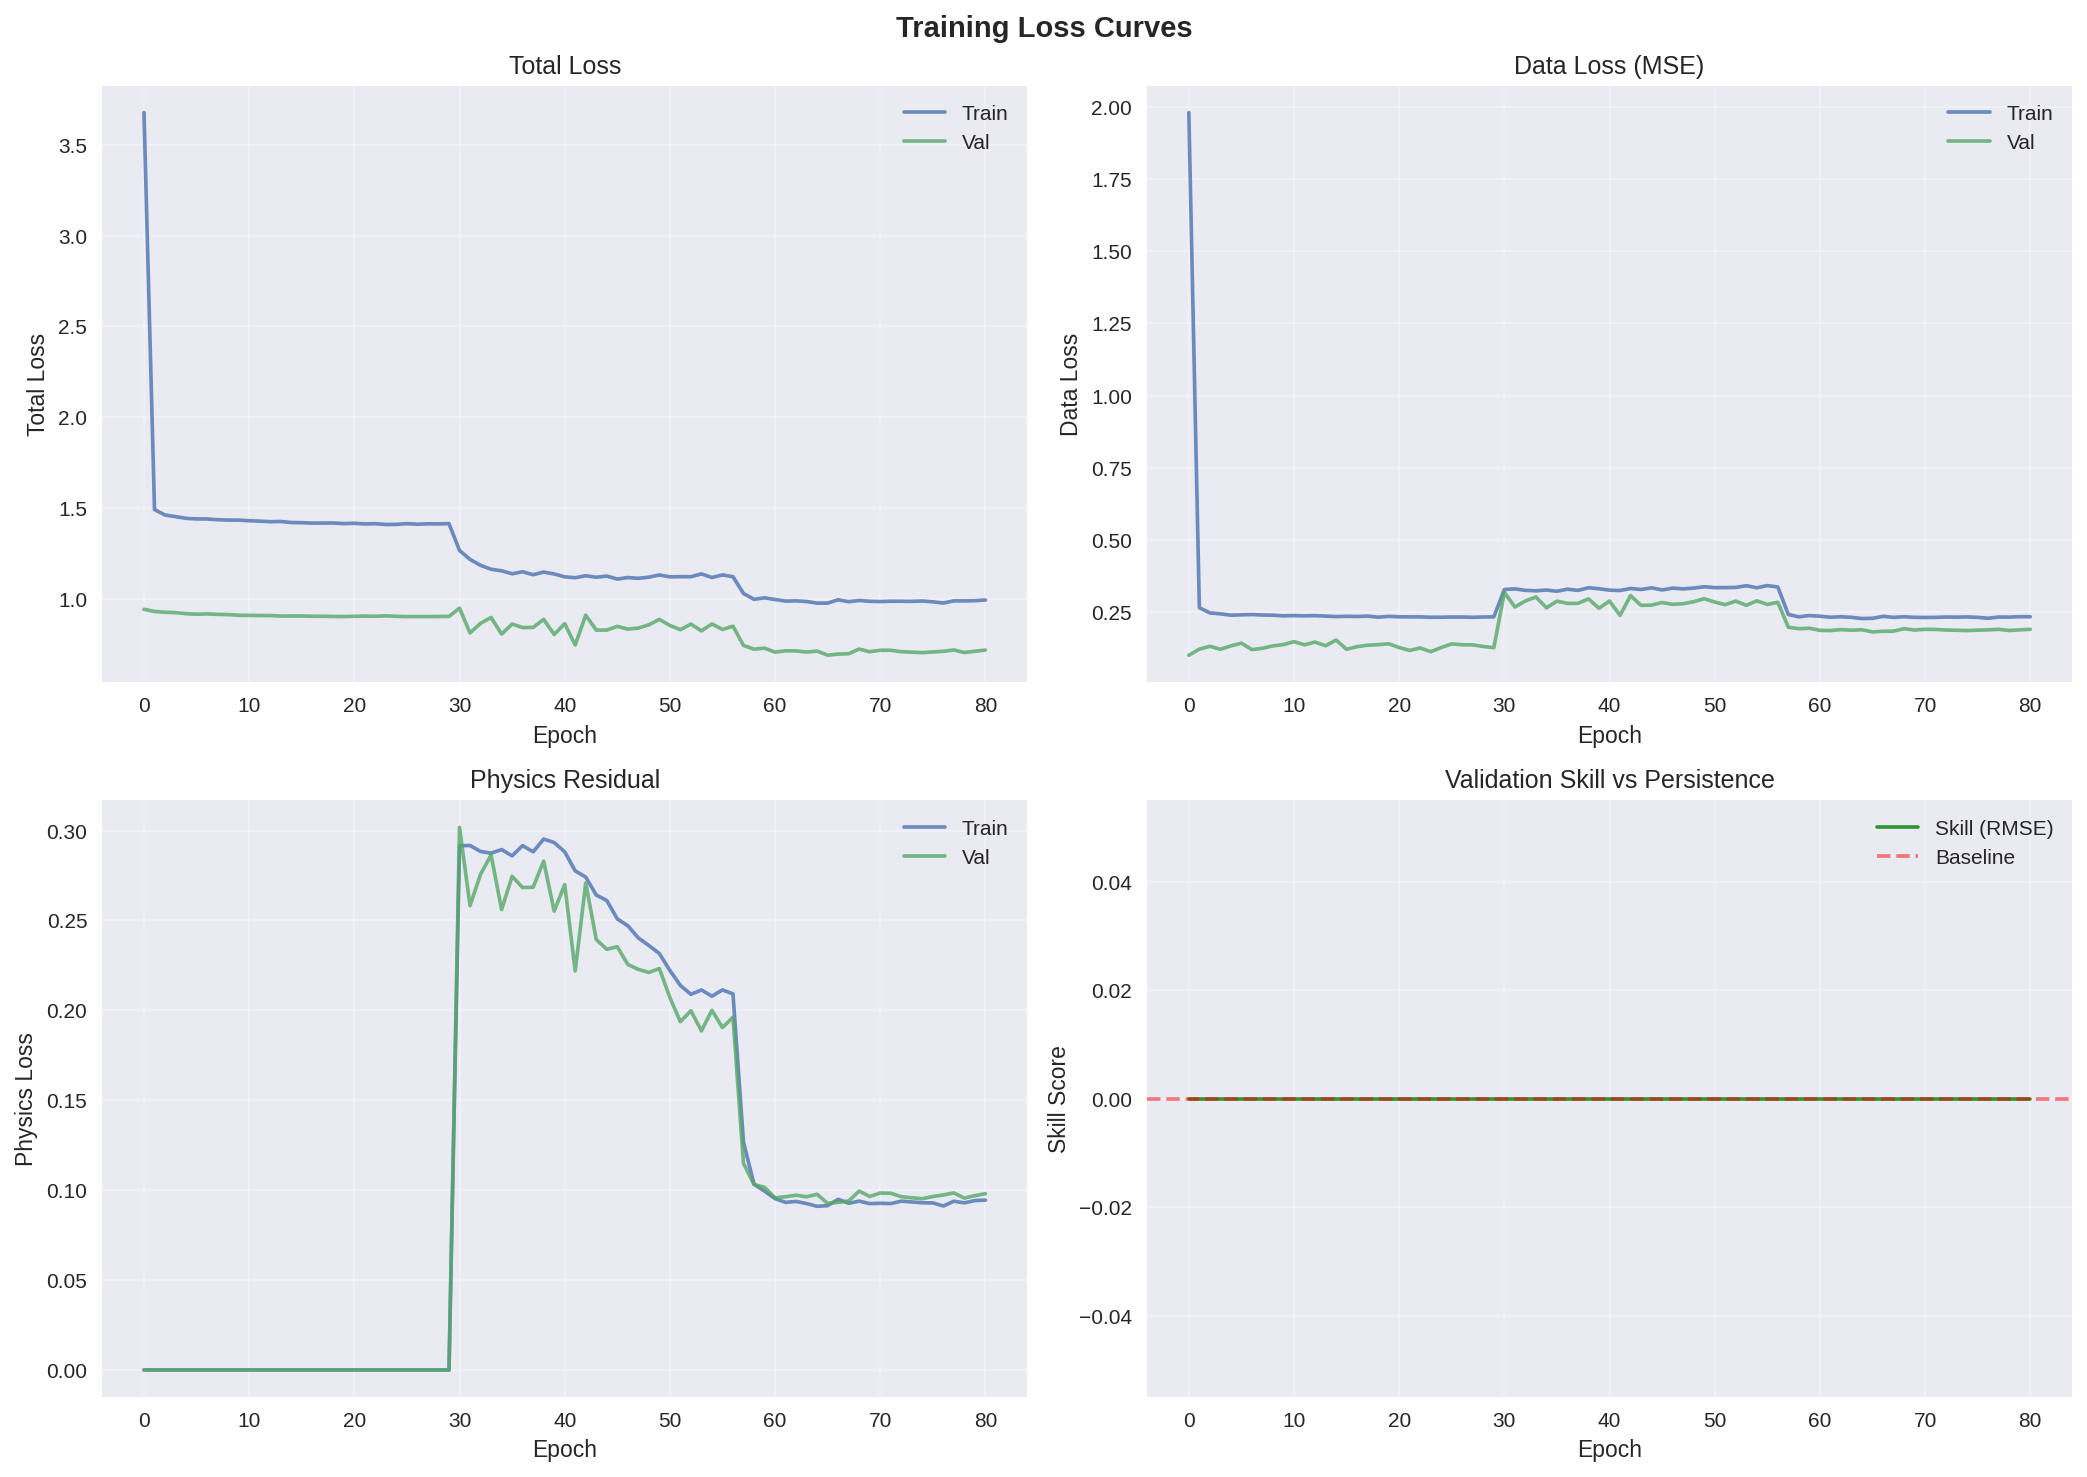

In [9]:
from IPython.display import Image, display
import os

# Display loss curves
plot_path = '/content/pinn_training/artifacts/plots_gpu/loss_curves.png'
if os.path.exists(plot_path):
    print("Training Loss Curves:")
    display(Image(filename=plot_path))
else:
    print("Plot not found. Checking directory...")
    !ls -la /content/pinn_training/artifacts/plots_gpu/

## Step 8: View Evaluation Results

In [10]:
import json

# Load metrics
metrics_path = '/content/pinn_training/results/surrogate_eval_colab/surrogate_metrics.json'
with open(metrics_path, 'r') as f:
    metrics = json.load(f)

print("="*60)
print("FINAL EVALUATION RESULTS")
print("="*60)
print(f"\nPINN Performance:")
print(f"  MAE: {metrics['pinn']['mae_celsius']:.2f}°C")
print(f"  RMSE: {metrics['pinn']['rmse_celsius']:.2f}°C")
print(f"  Samples: {metrics['pinn']['n_samples']}")

print(f"\nRF Baseline:")
print(f"  MAE: {metrics['rf']['mae_celsius']:.2f}°C")
print(f"  RMSE: {metrics['rf']['rmse_celsius']:.2f}°C")

print(f"\nComparison:")
if metrics['pinn']['mae_celsius'] < metrics['rf']['mae_celsius']:
    improvement = (metrics['rf']['mae_celsius'] - metrics['pinn']['mae_celsius']) / metrics['rf']['mae_celsius'] * 100
    print(f"  ✓ PINN is {improvement:.1f}% BETTER than RF!")
    print(f"  Target achieved: PINN MAE < 5°C" if metrics['pinn']['mae_celsius'] < 5.0 else "  Close to target")
else:
    degradation = (metrics['pinn']['mae_celsius'] - metrics['rf']['mae_celsius']) / metrics['rf']['mae_celsius'] * 100
    print(f"  PINN is {degradation:.1f}% worse than RF")
    print(f"  Note: May need more training or hyperparameter tuning")

FINAL EVALUATION RESULTS

PINN Performance:
  MAE: 8.39°C
  RMSE: 8.39°C
  Samples: 1074

RF Baseline:
  MAE: 4.05°C
  RMSE: 7.51°C

Comparison:
  PINN is 106.9% worse than RF
  Note: May need more training or hyperparameter tuning


## Step 9: Display Comparison Plot

Model Comparison:


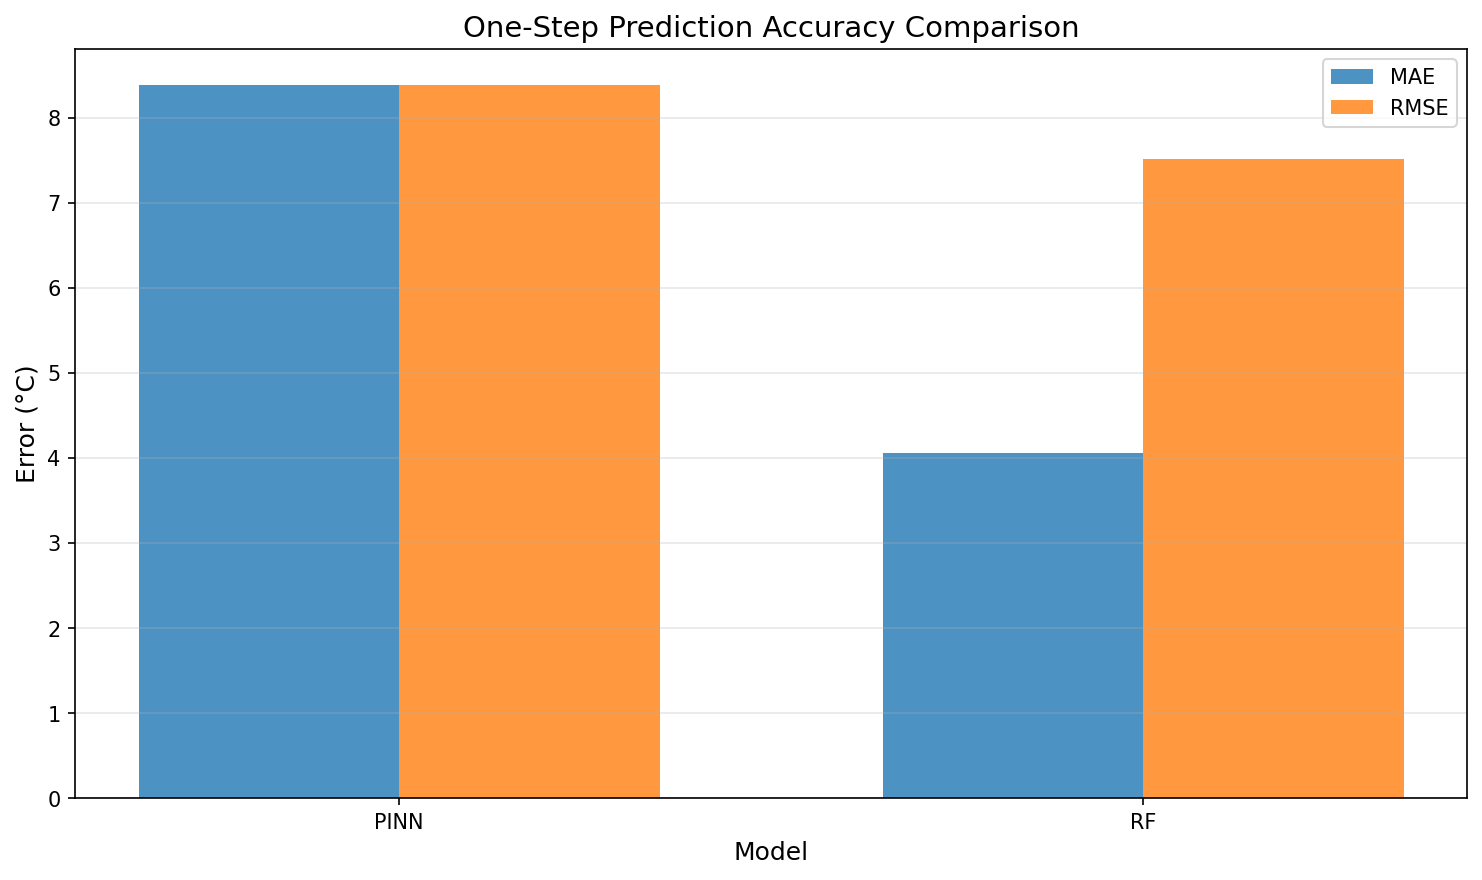

In [11]:
from IPython.display import Image, display

# Display model comparison plot
comparison_plot = '/content/pinn_training/results/surrogate_eval_colab/model_comparison.png'
if os.path.exists(comparison_plot):
    print("Model Comparison:")
    display(Image(filename=comparison_plot))
else:
    print("Comparison plot not found")

## Step 10: Package Results for Download

In [12]:
import shutil

# Create results package
results_dir = '/content/results_package'
os.makedirs(results_dir, exist_ok=True)

print("Packaging results...")

# Copy important files
shutil.copy('/content/pinn_training/artifacts/best_model.pt',
            f'{results_dir}/best_model.pt')
shutil.copy('/content/pinn_training/artifacts/final_model.pt',
            f'{results_dir}/final_model.pt')

# Copy plots
if os.path.exists('/content/pinn_training/artifacts/plots_gpu'):
    shutil.copytree('/content/pinn_training/artifacts/plots_gpu',
                    f'{results_dir}/plots', dirs_exist_ok=True)

# Copy evaluation results
if os.path.exists('/content/pinn_training/results/surrogate_eval_colab'):
    shutil.copytree('/content/pinn_training/results/surrogate_eval_colab',
                    f'{results_dir}/evaluation', dirs_exist_ok=True)

# Copy training logs
if os.path.exists('/content/pinn_training/artifacts/logs_gpu'):
    shutil.copytree('/content/pinn_training/artifacts/logs_gpu',
                    f'{results_dir}/logs', dirs_exist_ok=True)

# Create ZIP
shutil.make_archive('/content/pinn_results', 'zip', results_dir)

print("Results packaged successfully!")
print(f"\nPackage contents:")
!ls -lh /content/results_package/

Packaging results...


FileNotFoundError: [Errno 2] No such file or directory: '/content/pinn_training/artifacts/final_model.pt'

## Step 11: Download Results

In [ ]:
from google.colab import files

# Download the results ZIP
print("Downloading results...")
files.download('/content/pinn_results.zip')

print("\n" + "="*60)
print("TRAINING COMPLETE!")
print("="*60)
print("\nDownload started! Check your browser's download folder.")
print("\nPackage includes:")
print("  - best_model.pt (best checkpoint)")
print("  - final_model.pt (final checkpoint)")
print("  - plots/ (training curves)")
print("  - evaluation/ (metrics and comparison plots)")
print("  - logs/ (training logs)")
print("\nNext steps:")
print("  1. Extract pinn_results.zip locally")
print("  2. Copy files to your project artifacts/")
print("  3. Proceed with Week 10 ablation study or Week 13-15 RL training")

---

## Troubleshooting

If you encounter issues:

1. **GPU not available**: Runtime → Change runtime type → GPU → Save
2. **Out of memory**: Restart runtime and reduce batch size in config
3. **Upload fails**: Try uploading to Google Drive and mounting it instead
4. **Training crashes**: Check error messages and verify all files are present

For detailed troubleshooting, see `COLAB_TRAINING_GUIDE.md` in your project.